# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [ ]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np


# Data Visualisation
import matplotlib.pyplot as plt


# Machine Learning Utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV


# Data Preprocessing
from sklearn.preprocessing import LabelEncoder


# Classification Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)


# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Model Saving
import joblib



# 1. Business Understanding

## Project Background

Student academic performance is an important indicator of future educational success. However, schools often face challenges in identifying students who may struggle academically before final examination results are released. Without early intervention, students at risk of poor performance may miss opportunities for additional academic support and personalised learning.

## Project Goal

The objective of this project is to develop a machine learning classification model that predicts a student's final grade category (A, B, C, or D) using demographic, family, social, and academic information from the Student Performance dataset. By predicting a student's likely final grade before results are released, the model can assist educators in identifying students who may require additional support and enable schools to make more informed, data-driven decisions.

## Business Impact

An accurate prediction model can support teachers and school administrators in monitoring student performance, prioritising academic interventions, and allocating educational resources more effectively. Early identification of at-risk students allows timely support to be provided, which may improve overall academic performance and student outcomes.


# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH= "student grade prediction.xlsx"
df = pd.read_excel(FILE_PATH, sheet_name="student-por") ## Read the data from the excel file")
df ## Display dataframe



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


## 2.2 Summary Statistics

Before preprocessing the dataset, it is important to understand its structure and quality. This section examines the dataset's dimensions, data types, missing values, and summary statistics to identify any potential issues that may affect model performance.

In [3]:
# Display the dimensions of the dataset
df.shape

(649, 33)

In [4]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

The dataset contains 649 student records and 33 features. It consists of both numerical and categorical variables

In [5]:
## Check for missing data
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

No missing values were found in the dataset. Therefore, no data imputation is required, and all records can be retained for further analysis.

In [6]:
## Describe data distribution

print("Numerical Features")
display(df.describe())

print("Categorical Features")
display(df.describe(include="object"))

Numerical Features


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


Categorical Features


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


The summary statistics provide an overview of the numerical features, including their minimum, maximum, mean, and standard deviation. Features such as age, studytime, absences, and previous grades (G1, G2, and G3) show variation across students, suggesting that these factors may influence academic performance.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

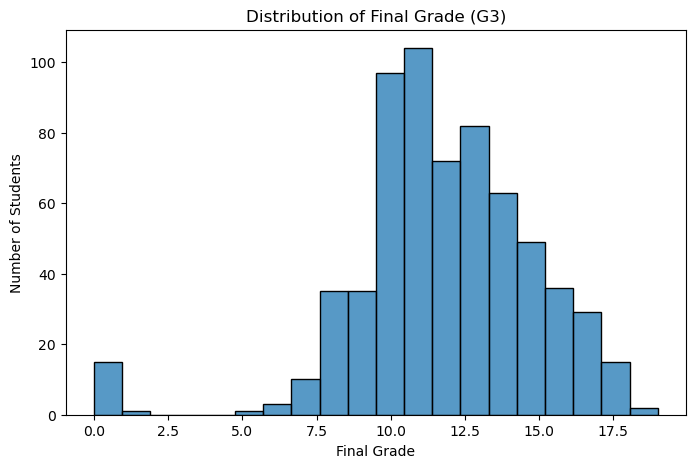

In [7]:
# Display the distribution of the final grade (G3)
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["G3"], bins=20)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

The distribution of G3 shows how students performed in the final examination. Most students achieved mid-range scores around 10 while relatively few obtained either very low or very high marks. Understanding this distribution helps determine whether the target variable is balanced before it is converted into grade categories.

### 2.3.1.2 Understanding distribution of features

## Study Time

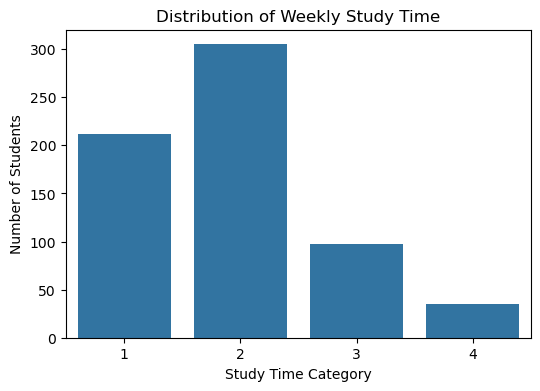

In [8]:

# Display the distribution of weekly study time

plt.figure(figsize=(6,4))
sns.countplot(x="studytime", data=df)

plt.title("Distribution of Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

Most students fall within the lower to moderate study time categories, while relatively few spend the highest amount of time studying. This suggests that study habits vary among students and may influence academic performance.

# Absences

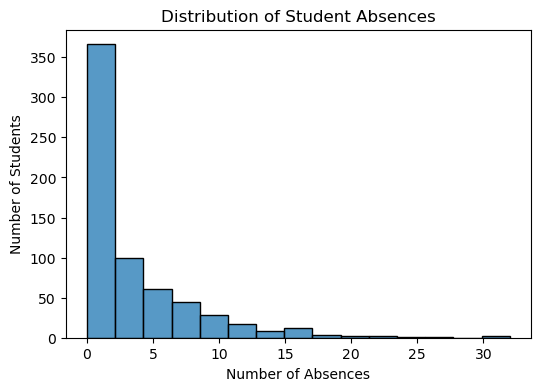

In [9]:
# Display the distribution of student absences

plt.figure(figsize=(6,4))
sns.histplot(df["absences"], bins=15)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

plt.show()

Most students have relatively few absences, while a small number have significantly higher absenteeism. These extreme values may represent outliers and could influence model performance.

# Failures

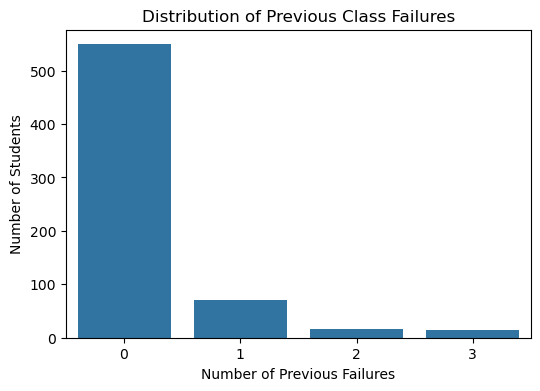

In [10]:
# Display the distribution of previous class failures

plt.figure(figsize=(6,4))
sns.countplot(x="failures", data=df)

plt.title("Distribution of Previous Class Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

The majority of students have no previous class failures, while only a small proportion have failed. Previous failures may be an important indicator of future academic performance.

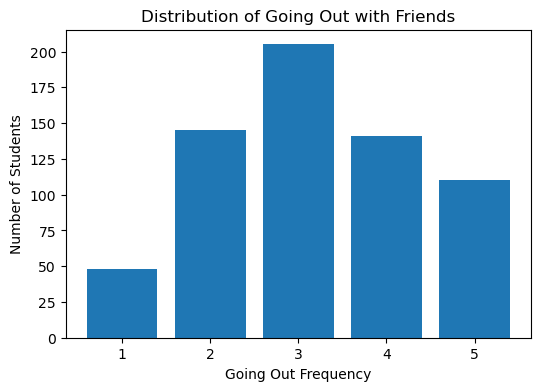

In [11]:
# Distribution of Going Out with Friends

goout_counts = df["goout"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(goout_counts.index.astype(str), goout_counts.values)

plt.title("Distribution of Going Out with Friends")
plt.xlabel("Going Out Frequency")
plt.ylabel("Number of Students")

plt.show()

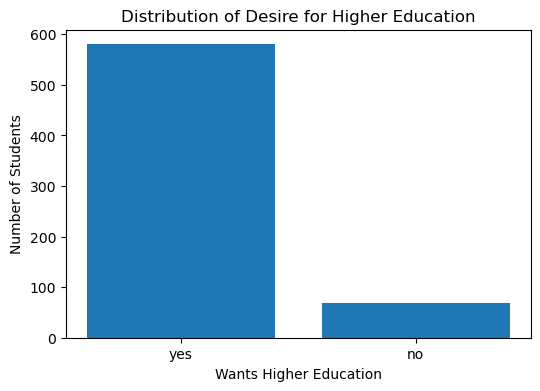

In [12]:
# Distribution of Desire for Higher Education

higher_counts = df["higher"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(higher_counts.index, higher_counts.values)

plt.title("Distribution of Desire for Higher Education")
plt.xlabel("Wants Higher Education")
plt.ylabel("Number of Students")

plt.show()

### 2.3.2 Understanding relationship between variables

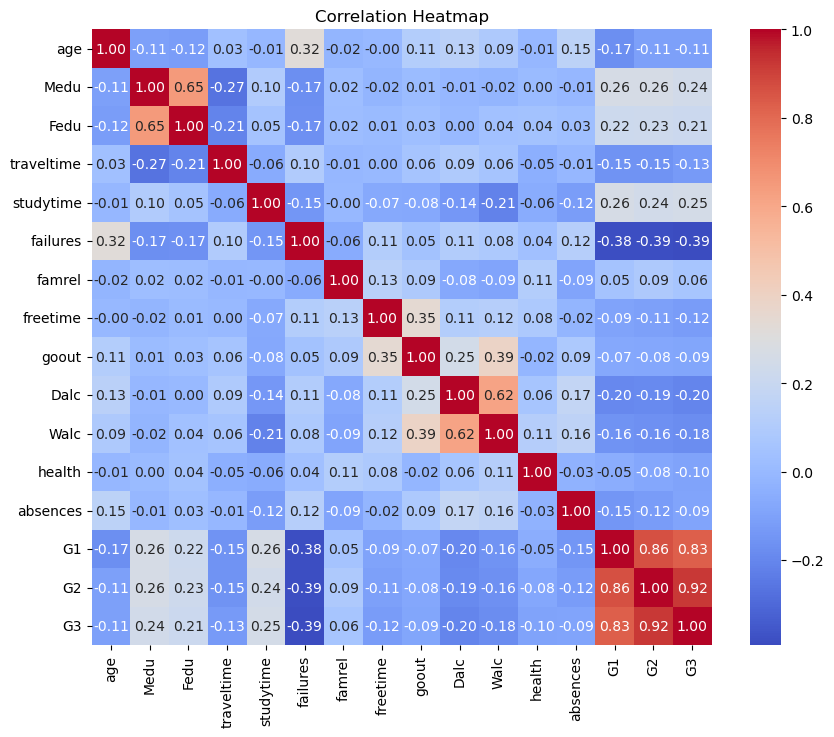

In [13]:
# Display the correlation between numerical features

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows that G1 and G2 have the strongest positive correlations with G3, indicating that previous academic performance is closely related to final examination results. Most of the remaining features show relatively weak individual correlations with G3. This suggests that student performance is influenced by multiple factors rather than a single variable. Therefore, feature importance will be further evaluated during model training instead of relying solely on correlation analysis.}

## key features vs target

### study time vs g3

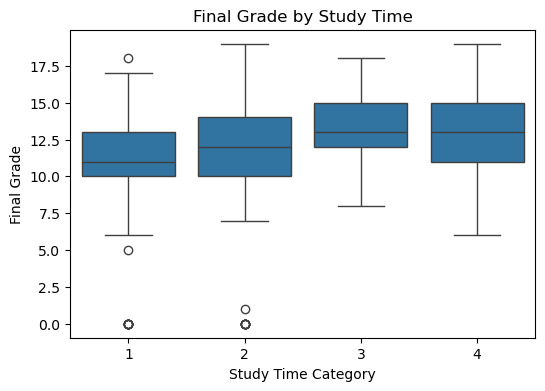

In [14]:
# Compare final grades across study time categories

plt.figure(figsize=(6,4))
sns.boxplot(x="studytime", y="G3", data=df)

plt.title("Final Grade by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")

plt.show()

### g3 vs failures

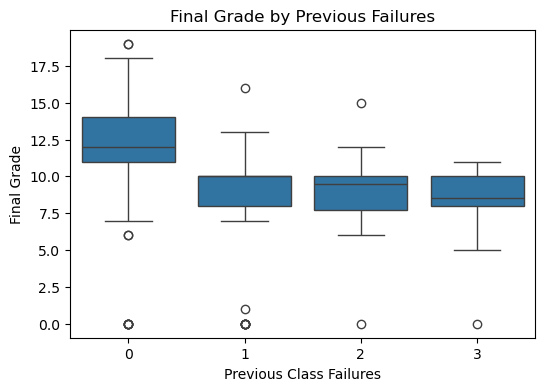

In [15]:
# Compare final grades across previous failure categories

plt.figure(figsize=(6,4))
sns.boxplot(x="failures", y="G3", data=df)

plt.title("Final Grade by Previous Failures")
plt.xlabel("Previous Class Failures")
plt.ylabel("Final Grade")

plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning


Data cleaning ensures that the dataset is suitable for machine learning by checking for duplicate records and handling any data quality issues. Since missing values were previously examined during data understanding, this section focuses on identifying duplicate entries before model training.

In [16]:
# Check for duplicate rows and missing values in the dataset

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
print(df.isnull().sum())

Duplicate rows: 0
Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [17]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']



Since this project is a classification task, the original final examination score (G3) is converted into four grade categories (A, B, C, and D). These grade categories will serve as the target variable for training the classification models.

In [18]:


# Convert the numerical final grade (G3) into grade categories
def convert_grade(score):
    if score >= 16:
        return "A"
    elif score >= 11:
        return "B"
    elif score >= 6:
        return "C"
    else:
        return "D"

df["Grade"] = df["G3"].apply(convert_grade)

# Check the new target variable
df[["G3", "Grade"]].head()

,G3,Grade
0,11,B
1,11,B
2,12,B
3,14,B
4,13,B


In [19]:
# Display the distribution of the target variable
df["Grade"].value_counts().sort_index()

Grade
A     82
B    370
C    180
D     17
Name: count, dtype: int64

In [20]:
df.drop(columns=["G3"], inplace=True)
df.drop(columns=["G1"], inplace=True)


G3 was removed because it was used to create the target variable (Grade), preventing data leakage during model training. G1 was also removed to reduce redundancy, as G2 is a more recent measure of student performance.

In [21]:
# # Feature Engineering

# # Combine parents' education levels
# df["Parent_Education"] = (df["Medu"] + df["Fedu"]) / 2

# # Combine weekday and weekend alcohol consumption
# df["Total_Alcohol"] = df["Dalc"] + df["Walc"]

# df.head()

Feature Engineering:
Two new features were created to provide more meaningful representations of the original data. Parent_Education combines the education levels of both parents into a single feature representing the overall educational background of the household. Total_Alcohol combines weekday and weekend alcohol consumption into a single feature representing the student's overall alcohol consumption.

In [22]:
# # Feature Selection

# # Remove original columns after creating the new features
# df.drop(columns=["Medu", "Fedu", "Dalc", "Walc"], inplace=True)

# df.head()

Feature Selection:
After creating the new features, the original columns were removed to reduce redundancy and prevent overlapping information from being provided to the machine learning models.

In [23]:
# Store categorical features (excluding the target)
categorical_features = df.select_dtypes(include="object").drop(columns=["Grade"]).columns

categorical_features

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [24]:
# Apply one-hot encoding to categorical features
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

The dataset contains several categorical features stored as text values. These features must be converted into numerical format before they can be used by machine learning algorithms.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                649 non-null    int64 
 1   Medu               649 non-null    int64 
 2   Fedu               649 non-null    int64 
 3   traveltime         649 non-null    int64 
 4   studytime          649 non-null    int64 
 5   failures           649 non-null    int64 
 6   famrel             649 non-null    int64 
 7   freetime           649 non-null    int64 
 8   goout              649 non-null    int64 
 9   Dalc               649 non-null    int64 
 10  Walc               649 non-null    int64 
 11  health             649 non-null    int64 
 12  absences           649 non-null    int64 
 13  G2                 649 non-null    int64 
 14  Grade              649 non-null    object
 15  school_MS          649 non-null    bool  
 16  sex_M              649 non-null    bool  
 1

In [26]:
# Convert target labels into integers
grade_mapping = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3
}

df["Grade"] = df["Grade"].map(grade_mapping)

# Display the encoded target values
df["Grade"].value_counts().sort_index()
# Integer encoding is applied to the target variable because
# machine learning classification models require numerical labels.

Grade
0     82
1    370
2    180
3     17
Name: count, dtype: int64

In [27]:
# Display the dataset after preprocessing
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


In [28]:
# Display dataset information after preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                649 non-null    int64
 1   Medu               649 non-null    int64
 2   Fedu               649 non-null    int64
 3   traveltime         649 non-null    int64
 4   studytime          649 non-null    int64
 5   failures           649 non-null    int64
 6   famrel             649 non-null    int64
 7   freetime           649 non-null    int64
 8   goout              649 non-null    int64
 9   Dalc               649 non-null    int64
 10  Walc               649 non-null    int64
 11  health             649 non-null    int64
 12  absences           649 non-null    int64
 13  G2                 649 non-null    int64
 14  Grade              649 non-null    int64
 15  school_MS          649 non-null    bool 
 16  sex_M              649 non-null    bool 
 17  address_U       

In [29]:
df["Grade"].head()

0    1
1    1
2    1
3    1
4    1
Name: Grade, dtype: int64

The target variable (Grade) was integer encoded to represent each grade category as a numerical class label. Unlike input features, integer encoding is appropriate for the target variable because the model predicts class labels rather than using them as input features.

## 3.2 Train-Test Split


The dataset is split into training and testing sets before model training. The training set is used to train the machine learning models, while the testing set is used to evaluate model performance on unseen data. An 80:20 split is used with a fixed random state to ensure reproducible results.

In [30]:
# Separate the features (X) and target variable (y)
X = df.drop(columns=["Grade"])
y = df["Grade"]

In [31]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# Display the size of each dataset
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (519, 40)
X_test: (130, 40)
y_train: (519,)
y_test: (130,)


The dataset was successfully divided into training and testing sets using an 80:20 ratio. The training set is used to train the machine learning models, while the testing set is reserved for evaluating model performance on unseen data. Stratified sampling was applied to preserve the distribution of grade categories in both datasets.

# 4. Modelling

Three classification models are trained and evaluated using the training dataset. Their performance is then compared using the testing dataset to identify the most suitable model for predicting student grade categories.

## 4.1 Logistic Regression

Logistic Regression is used as the baseline model because it is a simple and effective algorithm for multiclass classification problems. It provides a benchmark for comparing the performance of other machine learning models.

In [33]:
# # Initialise the Logistic Regression model
logistic_model = LogisticRegression(
     max_iter=1000,
     random_state=42
 )


In [34]:
# # Train the Logistic Regression model
logistic_model.fit(X_train, y_train)

c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:
# Predict the grade categories for the testing dataset
y_pred_lr = logistic_model.predict(X_test)

In [36]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_lr, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_lr, average="weighted"))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.8538461538461538
Precision: 0.860991182730313
Recall   : 0.8538461538461538
F1-score : 0.855011655011655
              precision    recall  f1-score   support

           0       0.73      0.94      0.82        17
           1       0.91      0.85      0.88        74
           2       0.83      0.83      0.83        36
           3       0.67      0.67      0.67         3

    accuracy                           0.85       130
   macro avg       0.79      0.82      0.80       130
weighted avg       0.86      0.85      0.86       130

[[16  1  0  0]
 [ 6 63  5  0]
 [ 0  5 30  1]
 [ 0  0  1  2]]


### Interpretation

The Logistic Regression model achieved an accuracy of **85.38%** on the testing dataset. It also achieved a weighted precision of **86.10%**, weighted recall of **85.38%**, and weighted F1-score of **85.50%**, indicating good overall classification performance.

From the classification report, the model performed best on Grade B and Grade C, achieving high precision and recall. Grade A was also classified well, although a few Grade A students were predicted as Grade B. The model showed lower performance for Grade D due to the small number of Grade D samples in the dataset, making it more difficult for the model to learn this class.

Overall, Logistic Regression provides a strong baseline model for predicting student grade categories and will be compared with other classification models.

# 4.2 Decision Tree

Decision Tree is trained to compare its performance against Logistic Regression. Unlike Logistic Regression, Decision Tree can capture non-linear relationships and is easy to interpret through its tree-based structure.

In [37]:
# Initialise the Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [38]:

# Predict the testing dataset
y_pred_dt = dt_model.predict(X_test)

In [39]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_dt, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_dt, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_dt))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.7307692307692307
Precision: 0.7339705041255503
Recall   : 0.7307692307692307
F1-score : 0.7290734318985918
              precision    recall  f1-score   support

           0       0.65      0.88      0.75        17
           1       0.78      0.77      0.78        74
           2       0.71      0.61      0.66        36
           3       0.33      0.33      0.33         3

    accuracy                           0.73       130
   macro avg       0.62      0.65      0.63       130
weighted avg       0.73      0.73      0.73       130

[[15  2  0  0]
 [ 8 57  9  0]
 [ 0 12 22  2]
 [ 0  2  0  1]]


### Interpretation

The Decision Tree model achieved an accuracy of **73.08%**, which is lower than the Logistic Regression model. The weighted precision, recall, and F1-score were also lower, indicating weaker overall classification performance.

The model performed reasonably well in predicting Grade B but showed lower performance for Grades C and D. This may be because Decision Trees are prone to overfitting, especially when using the default parameters.

Overall, the Decision Tree model provides a useful comparison but does not outperform Logistic Regression on this dataset.

# 4.3 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is trained to compare its performance against Logistic Regression and Decision Tree.

In [40]:
# Initialise the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict the testing dataset
y_pred_rf = rf_model.predict(X_test)




In [41]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_rf, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_rf))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8307692307692308
Precision: 0.8115758330738088
Recall   : 0.8307692307692308
F1-score : 0.8203333333333335
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        17
           1       0.86      0.88      0.87        74
           2       0.79      0.86      0.83        36
           3       0.00      0.00      0.00         3

    accuracy                           0.83       130
   macro avg       0.61      0.61      0.61       130
weighted avg       0.81      0.83      0.82       130

[[12  5  0  0]
 [ 3 65  6  0]
 [ 0  5 31  0]
 [ 0  1  2  0]]


c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afsh

In [42]:
# Feature Importance (Random Forest)

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
13,G2,0.343305
12,absences,0.047750
5,failures,0.041308
0,age,0.032584
7,freetime,0.030149
8,goout,0.029101
10,Walc,0.027794
2,Fedu,0.027677
14,school_MS,0.025449
11,health,0.025253


### Interpretation

The Random Forest model achieved an accuracy of **83.08%**, with a weighted precision of **81.16%**, weighted recall of **83.08%**, and weighted F1-score of **82.03%**.

Compared to the Decision Tree model, Random Forest achieved better overall performance, demonstrating the benefit of combining multiple decision trees to improve prediction accuracy and reduce overfitting. However, the model did not outperform Logistic Regression on this dataset.

Overall, Random Forest is a strong classification model but is currently the second-best performing model based on the evaluation metrics.

# 4.4 Gradient Boosting

Gradient Boosting is an ensemble learning algorithm that builds decision trees sequentially, where each new tree attempts to correct the errors made by the previous trees. It is evaluated to compare its performance with the other classification models.

In [43]:
# Initialise the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict the testing dataset
y_pred_gb = gb_model.predict(X_test)

In [44]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_gb, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_gb, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_gb))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_gb))

Accuracy : 0.8461538461538461
Precision: 0.8553380087726833
Recall   : 0.8461538461538461
F1-score : 0.8471693823417962
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.89      0.85      0.87        74
           2       0.85      0.81      0.83        36
           3       1.00      0.67      0.80         3

    accuracy                           0.85       130
   macro avg       0.86      0.82      0.82       130
weighted avg       0.86      0.85      0.85       130

[[16  1  0  0]
 [ 7 63  4  0]
 [ 0  7 29  0]
 [ 0  0  1  2]]


In [45]:
# Create a summary table comparing all models

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted"),
        precision_score(y_test, y_pred_dt, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_gb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_gb, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_gb, average="weighted")
    ]
})

comparison

c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.853846,0.860991,0.853846,0.855012
1,Decision Tree,0.730769,0.733971,0.730769,0.729073
2,Random Forest,0.830769,0.811576,0.830769,0.820333
3,Gradient Boosting,0.846154,0.855338,0.846154,0.847169


## 4.6 Model Selection

Based on the comparison results, Logistic Regression was selected for hyperparameter tuning because it achieved the highest overall performance while remaining computationally efficient and easy to interpret. Improving the strongest baseline model is a standard machine learning practice and allows the impact of hyperparameter tuning to be evaluated against an established baseline.

# 5. Hyperparameter Tuning
## 5.1 Hyperparameter Tuning


Logistic Regression achieved the best performance among the four baseline models and was selected for further optimisation.

Hyperparameter tuning is performed to identify a combination of parameters that may improve the model's predictive performance compared to the baseline model. A reproducible setup is used with a fixed random state and 5-fold cross-validation.

In [46]:
# Define the hyperparameter search space
param_dist = {
    "C": [0.01, 0.1, 1, 10, 100],
     "solver": ["liblinear", "lbfgs", "newton-cg"]
}

In [47]:
# Perform Randomized Search
random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search.fit(X_train, y_train)

c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from

In [48]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'solver': 'newton-cg', 'C': 0.1}

Best Cross Validation Accuracy:
0.834353995519044


In [49]:
results = pd.DataFrame(random_search.cv_results_)

results[
    [
        "params",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,params,mean_test_score,rank_test_score
4,"{'solver': 'newton-cg', 'C': 0.1}",0.834354,1
9,"{'solver': 'lbfgs', 'C': 0.1}",0.834354,1
5,"{'solver': 'newton-cg', 'C': 1}",0.826606,3
1,"{'solver': 'newton-cg', 'C': 10}",0.820818,4
8,"{'solver': 'newton-cg', 'C': 100}",0.809279,5
3,"{'solver': 'lbfgs', 'C': 100}",0.801568,6
6,"{'solver': 'newton-cg', 'C': 0.01}",0.763144,7
7,"{'solver': 'lbfgs', 'C': 0.01}",0.763144,7
0,"{'solver': 'liblinear', 'C': 10}",NaN,9
2,"{'solver': 'liblinear', 'C': 0.01}",NaN,9


In [50]:
# Train the best model
best_model = random_search.best_estimator_

# Predict on the test set
y_pred_tuned = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_tuned, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_tuned, average="weighted"))

print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

Accuracy : 0.8384615384615385
Precision: 0.8425414781297135
Recall   : 0.8384615384615385
F1-score : 0.8357503244080425
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        17
           1       0.87      0.88      0.87        74
           2       0.82      0.78      0.80        36
           3       1.00      0.33      0.50         3

    accuracy                           0.84       130
   macro avg       0.86      0.72      0.75       130
weighted avg       0.84      0.84      0.84       130

[[15  2  0  0]
 [ 5 65  4  0]
 [ 0  8 28  0]
 [ 0  0  2  1]]


### Hyperparameter Tuning Interpretation

Hyperparameter tuning was performed on the Logistic Regression model by varying the regularisation strength (`C`) and optimisation solver using RandomizedSearchCV with 5-fold cross-validation.

The best parameter combination obtained was:

- Solver: `newton-cg`
- C: `0.1`

Although the tuned model performed well, it achieved a test accuracy of **83.85%**, which was slightly lower than the baseline Logistic Regression model (**85.38%**).

This indicates that the default Logistic Regression parameters were already well suited for this dataset. Therefore, the baseline Logistic Regression model was selected as the final model.

# 6. Evaluation Metric Selection

Accuracy was selected as the primary evaluation metric because the objective of this project is to correctly classify students into their final grade categories.

Precision, recall, and F1-score were also evaluated to provide a more complete assessment of model performance, especially since the dataset contains multiple grade categories with different numbers of samples.

The baseline Logistic Regression model achieved the highest overall accuracy while maintaining strong precision, recall, and F1-score. This indicates that the model is able to classify student performance reliably and can support educators in identifying students who may require additional academic support.

## Testing on Unseen Data

In [51]:
y_pred_unseen = logistic_model.predict(X_test)

In [52]:
grade_map = {
    0: "A",
    1: "B",
    2: "C",
    3: "D"
}

actual_grades = y_test.reset_index(drop=True).map(grade_map)
predicted_grades = pd.Series(y_pred_unseen).map(grade_map)

results = pd.DataFrame({
    "Actual Grade": actual_grades,
    "Predicted Grade": predicted_grades
})

display(results.head(10))

,Actual Grade,Predicted Grade
0,C,C
1,C,C
2,C,B
3,B,B
4,C,C
5,A,A
6,A,A
7,C,C
8,C,B
9,C,C


In [53]:
import joblib

# Save the final Logistic Regression model
joblib.dump(logistic_model, "student_grade_model.pkl")

print("Model saved successfully.")

# Load the saved model
loaded_model = joblib.load("student_grade_model.pkl")

print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


In [54]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

print("Feature names saved successfully.")

Feature names saved successfully.


## Iterative model development


The machine learning model was developed through several iterations to improve its performance.

Initially, four baseline classification models (Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting) were trained and evaluated.

Feature engineering was performed by creating the Grade target variable from G3, removing G3 to prevent data leakage, removing G1 to reduce redundancy while retaining G2, and applying one-hot encoding to categorical features.

Logistic Regression achieved the highest baseline accuracy and was selected for hyperparameter tuning. After tuning the C and solver hyperparameters, the tuned model achieved slightly lower performance than the baseline model. Therefore, the baseline Logistic Regression model was retained as the final model because it produced the highest overall test accuracy.